In [1]:
# --- Colab setup (auto-inserted; no-op outside Colab). tag: colab-bootstrap ---
import sys
if "google.colab" in sys.modules:
    import os, subprocess, pathlib
    _slug = "aniryou/full-stack-agentic-engineer"
    _root = pathlib.Path("/content") / "full-stack-agentic-engineer"
    if not _root.exists():
        subprocess.run(["git", "clone", "--depth", "1", f"https://github.com/{_slug}.git", str(_root)], check=True)
    os.chdir(_root / "04-inference-engine/kv-cache")
    for _c in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (_c / "pyproject.toml").exists() or (_c / "setup.py").exists():
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(_c)]); break
        if (_c / "requirements.txt").exists():
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(_c / "requirements.txt")]); break
        if _c == _root:
            break
    if str(pathlib.Path.cwd()) not in sys.path:
        sys.path.insert(0, str(pathlib.Path.cwd()))


# KV Cache from Scratch — Worked Notebook

**Tier: T0 + PyTorch.** This notebook imports **PyTorch** and **matplotlib** and runs on a CPU: a laptop, or a
Colab CPU runtime, where both are preinstalled; locally, `pip install torch matplotlib`. A GPU is optional (the
timing cells use CUDA when one is present). Sizes are printed in binary units (KiB, GiB) with decimal GB in
brackets, as in the [primer](kv-cache-primer.md). The per-token timing cell takes under a minute
on a CPU (7–40 s on a shared 4-vCPU machine); the saved outputs below are from such a CPU run.

A runnable companion to the primer. Four ideas, in order:

1. **Attention re-reads all past K and V** every step — so cache them once.
2. **Cached generation gives *identical* output** to recomputing — same result, far less work.
3. **Per-token cost:** naive grows with sequence position, cached stays roughly flat.
4. **The cache is big** and lives in GPU memory — this is what bounds serving.

Everything is plain PyTorch. Random weights, so the generated tokens are gibberish —
that's fine, because the test is whether two code paths *agree*, not whether text is good.

> Notebook 02 is the fill-in-the-blank version. This one is also its answer key.

In [2]:
# Runs on CPU in a few seconds; uses GPU automatically if present.
# If needed:  pip install torch matplotlib
import math, time, torch, torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


## 1. Attention, with an optional cache

`forward` takes an optional `cache = (past_k, past_v)`. If given, it concatenates the
new token's K and V onto the past and returns the grown cache. Read the two commented
blocks — the concat, and the causal mask — that's the entire mechanism.

In [3]:
class CausalSelfAttention(nn.Module):
    """One multi-head causal attention block. K and V are what we will cache."""
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads  = n_heads
        self.head_dim = d_model // n_heads
        self.qkv  = nn.Linear(d_model, 3 * d_model, bias=False)   # makes Q, K, V
        self.proj = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, cache=None):
        # x: (B, T, C).  During prefill T = prompt length; during decode T = 1.
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)

        # (B, T, C) -> (B, n_heads, T, head_dim). The head_dim here sets cache size.
        split = lambda t: t.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        q, k, v = split(q), split(k), split(v)

        past_len = 0
        if cache is not None:                     # <-- THE CACHE, in two lines:
            past_k, past_v = cache                #     glue the new token's K, V
            past_len = past_k.shape[2]            #     onto everything we saw before,
            k = torch.cat([past_k, k], dim=2)     #     concatenating along the
            v = torch.cat([past_v, v], dim=2)     #     sequence (time) axis.
        new_cache = (k, v)                        # hand the grown cache back out

        # scores: each query dotted with every key -> (B, H, T, past_len + T)
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        # Causal mask by ABSOLUTE position. Query i sits at position past_len+i and
        # may look at key j only if j <= its own position. During decode the single
        # new query is at the end, so it legally sees the entire cache (no masking).
        q_pos = torch.arange(past_len, past_len + T, device=x.device).unsqueeze(1)
        k_pos = torch.arange(past_len + T,           device=x.device).unsqueeze(0)
        att = att.masked_fill(k_pos > q_pos, float("-inf")).softmax(dim=-1)

        y = (att @ v).transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(y), new_cache

## A tiny model

Just embedding → attention layers → output head. No MLP or LayerNorm, since neither
touches the cache. Each layer owns a cache, so caches are passed around as a **list**.

In [4]:
class MiniLM(nn.Module):
    """A stack of attention layers + embedding + output head.
    No MLP, no LayerNorm on purpose: neither touches the KV cache, so leaving them
    out keeps every line about caching. Random weights -> gibberish tokens, but the
    two code paths must still produce the SAME gibberish, which is the whole point.
    Each layer keeps its own cache, so 'caches' is a list, one entry per layer."""
    def __init__(self, vocab, d_model, n_heads, n_layers):
        super().__init__()
        self.emb    = nn.Embedding(vocab, d_model)
        self.layers = nn.ModuleList(
            CausalSelfAttention(d_model, n_heads) for _ in range(n_layers))
        self.head   = nn.Linear(d_model, vocab, bias=False)

    def forward(self, idx, caches=None):
        x = self.emb(idx)
        new_caches = []
        for i, layer in enumerate(self.layers):
            layer_cache = None if caches is None else caches[i]
            x, c = layer(x, layer_cache)
            new_caches.append(c)
        return self.head(x), new_caches

## 2. Two ways to generate

**Naive** re-feeds the entire sequence every step. **Cached** feeds the prompt once
(*prefill*), then one token at a time (*decode*), carrying the cache forward.

The single difference that matters: cached decode calls `model(next_id, caches)` with
**one** new token, not the whole history.

In [5]:
@torch.no_grad()
def generate_naive(model, prompt, n_new):
    """No cache: every step re-feeds the WHOLE sequence and recomputes all K, V."""
    idx = prompt
    for _ in range(n_new):
        logits, _ = model(idx)                             # reprocess everything
        next_id = logits[:, -1].argmax(-1, keepdim=True)   # greedy pick
        idx = torch.cat([idx, next_id], dim=1)
    return idx

In [6]:
@torch.no_grad()
def generate_cached(model, prompt, n_new):
    """With cache: process the prompt once (prefill), then feed ONE token per step."""
    logits, caches = model(prompt)                         # PREFILL: prompt, no cache
    next_id = logits[:, -1].argmax(-1, keepdim=True)
    out = [prompt, next_id]
    for _ in range(n_new - 1):
        logits, caches = model(next_id, caches)            # DECODE: 1 token + cache
        next_id = logits[:, -1].argmax(-1, keepdim=True)
        out.append(next_id)
    return torch.cat(out, dim=1)

### The payoff: same output, different cost

If the cache is implemented correctly, greedy decoding must produce the **exact same
token IDs** either way. This assert is the heart of the notebook.

In [7]:
model  = MiniLM(vocab=256, d_model=128, n_heads=4, n_layers=4).to(device).eval()
prompt = torch.randint(0, 256, (1, 16), device=device)

a = generate_naive(model,  prompt, 32)
b = generate_cached(model, prompt, 32)

print("naive :", a[0, -8:].tolist())
print("cached:", b[0, -8:].tolist())
print("IDENTICAL:", torch.equal(a, b))     # -> True : caching changes cost, not output

naive : [170, 170, 170, 170, 170, 170, 170, 170]
cached: [170, 170, 170, 170, 170, 170, 170, 170]
IDENTICAL: True


## How much work did we skip?

Naive reprocesses the whole prefix each step, so total work grows **quadratically**
with output length. Cached is **linear**. Counting token-forward-passes shows the gap.

In [8]:
# How much work did the cache save? Count "token-forward-passes": how many tokens
# get pushed through the model in total.
P, N = 16, 256
naive_passes  = sum(range(P, P + N))   # step t reprocesses t tokens
cached_passes = P + N                  # P for prefill, then 1 per step

print(f"naive : {naive_passes:>6} token-passes")
print(f"cached: {cached_passes:>6} token-passes")
print(f"cached does ~{naive_passes / cached_passes:.0f}x less token work "
      f"(and the gap widens as N grows)")

naive :  36736 token-passes
cached:    272 token-passes
cached does ~135x less token work (and the gap widens as N grows)


## 3. Where the cost shows up: per-token latency

This is the *decode* phase. Naive spends more time each step because the sequence it
reprocesses keeps getting longer; cached stays roughly flat (it only ever processes one
new token, though its attention still reads a slowly growing cache).

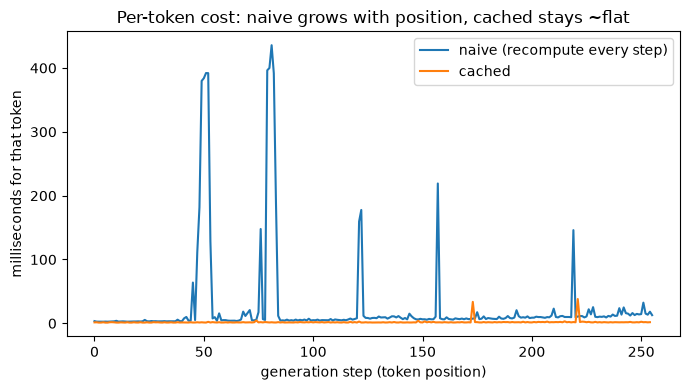

total naive : 6.62s
total cached: 0.49s


In [9]:
@torch.no_grad()
def per_step_times(model, prompt, n_new, use_cache):
    """Return seconds spent producing each successive token."""
    times = []
    if use_cache:
        logits, caches = model(prompt)
        next_id = logits[:, -1].argmax(-1, keepdim=True)
        for _ in range(n_new - 1):
            t0 = time.perf_counter()
            logits, caches = model(next_id, caches)
            next_id = logits[:, -1].argmax(-1, keepdim=True)
            if device == "cuda": torch.cuda.synchronize()
            times.append(time.perf_counter() - t0)
    else:
        idx = prompt
        for _ in range(n_new):
            t0 = time.perf_counter()
            logits, _ = model(idx)
            idx = torch.cat([idx, logits[:, -1].argmax(-1, keepdim=True)], dim=1)
            if device == "cuda": torch.cuda.synchronize()
            times.append(time.perf_counter() - t0)
    return times

# A slightly bigger model makes the trend obvious. Takes a few seconds.
big    = MiniLM(vocab=256, d_model=256, n_heads=8, n_layers=6).to(device).eval()
prompt = torch.randint(0, 256, (1, 32), device=device)
N = 256

naive_t  = per_step_times(big, prompt, N, use_cache=False)
cached_t = per_step_times(big, prompt, N, use_cache=True)

plt.figure(figsize=(7, 4))
plt.plot([t * 1e3 for t in naive_t],  label="naive (recompute every step)")
plt.plot([t * 1e3 for t in cached_t], label="cached")
plt.xlabel("generation step (token position)")
plt.ylabel("milliseconds for that token")
plt.title("Per-token cost: naive grows with position, cached stays ~flat")
plt.legend(); plt.tight_layout(); plt.show()

print(f"total naive : {sum(naive_t):.2f}s")
print(f"total cached: {sum(cached_t):.2f}s")

## 4. Why serving is a memory problem

The cache trades compute for memory — and that memory is real. It grows with
**every token × every user × every layer**, and it sits in the same finite GPU HBM as
the weights. Plug a real config into the formula from the primer:

In [10]:
def kv_cache_bytes(n_layers, n_kv_heads, head_dim, seq_len, batch=1, bytes_per=2):
    # x2 because we store BOTH K and V. bytes_per=2 is fp16.
    return 2 * n_layers * n_kv_heads * head_dim * seq_len * batch * bytes_per

# Llama 3 8B: 32 layers, 8 KV heads (grouped-query attention), head_dim 128, fp16.
KiB, GiB, GB = 1024, 1024 ** 3, 1e9          # binary units as in the primer; decimal GB in brackets
per_tok = kv_cache_bytes(32, 8, 128, seq_len=1)
print(f"per token              : {per_tok:,} bytes = {per_tok / KiB:.0f} KiB")
for label, tokens, batch in (("1 user @ 8,192 tokens", 8192, 1),
                             ("1 user @ 128,000 tokens", 128_000, 1),
                             ("32 users @ 8,192 tokens", 8192, 32)):
    b = kv_cache_bytes(32, 8, 128, tokens, batch=batch)
    print(f"{label:<23}: {b / GiB:6.2f} GiB ({b / GB:.2f} GB)")
print()
print("Model weights are a fixed ~16 GB (15 GiB) in fp16. On an 80 GB H100 the 32-user batch")
print("above already outweighs the model. The cache is the part that scales with")
print("traffic and context length -- which is why serving is a memory problem.")

per token              : 131,072 bytes = 128 KiB
1 user @ 8,192 tokens  :   1.00 GiB (1.07 GB)
1 user @ 128,000 tokens:  15.62 GiB (16.78 GB)
32 users @ 8,192 tokens:  32.00 GiB (34.36 GB)

Model weights are a fixed ~16 GB (15 GiB) in fp16. On an 80 GB H100 the 32-user batch
above already outweighs the model. The cache is the part that scales with
traffic and context length -- which is why serving is a memory problem.


## Recap

- K and V for past tokens never change, so we store them instead of recomputing — that
  is the whole cache (`torch.cat` along the time axis).
- Correct caching is **behaviour-preserving**: identical tokens, linear instead of
  quadratic cost.
- The saving turns generation into a **memory-bandwidth** job: each decode step must read
  the weights *and* the whole cache from HBM.
- Cache size scales with tokens, users, and layers — so context length and batch size are
  ultimately **memory** questions, which is exactly what GQA, quantization, and
  PagedAttention attack.

Now open **02** and rebuild the cache logic yourself.